In [12]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np 
import seaborn as sns

In [3]:
cars = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv")

In [4]:
cars

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,NaN,15.101802
9700,180,NaN,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


In [5]:
cars_ds = cars[['engine_displacement','horsepower','vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

In [6]:
cars_ds

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


In [9]:
#question 2
cars_ds['horsepower'].dropna().median()

np.float64(149.0)

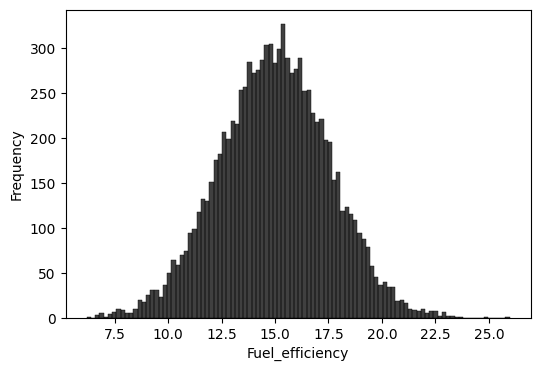

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(cars_ds.fuel_efficiency_mpg, bins = 100, color='black')
plt.ylabel('Frequency')
plt.xlabel('Fuel_efficiency')

plt.show()


In [16]:
cars_ds.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

# Validation Framework

In [17]:
np.random.seed(42)

In [20]:
n = len(cars_ds)

n_val = int(0.2*n)
n_test = int(0.2*n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.shuffle(idx)

cars_shuffled = cars_ds.iloc[idx]

cars_train = cars_shuffled.iloc[:n_train].copy()
cars_val = cars_shuffled.iloc[n_train:n_train+n_val].copy()
cars_test = cars_shuffled.iloc[n_train+n_val:]

In [25]:
#targets
y_train = cars_train.fuel_efficiency_mpg.values
y_val = cars_val.fuel_efficiency_mpg.values
y_test = cars_test.fuel_efficiency_mpg.values

# y_train = np.log1p
del cars_train['fuel_efficiency_mpg']
del cars_val["fuel_efficiency_mpg"]
del cars_test["fuel_efficiency_mpg"]

In [26]:
def fill_missing_value(df, filler_value):
    df_copy = df.copy()
    df_copy['horsepower'] = df_copy['horsepower'].fillna(filler_value)
    return df_copy




In [27]:
#Replace missing value with zero
cars_train_zero = fill_missing_value(cars_train, 0)
cars_val_zero = fill_missing_value(cars_val, 0)
cars_test_zero = fill_missing_value(cars_test, 0)

#Replace missing value with mean
cars_train_mean = fill_missing_value(cars_train, cars_train['horsepower'].mean())
cars_val_mean = fill_missing_value(cars_val, cars_val['horsepower'].mean())
cars_test_mean = fill_missing_value(cars_test, cars_test['horsepower'].mean())

In [38]:
#Linear Regression

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]



def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)



RMSR train  0.5202614265099076


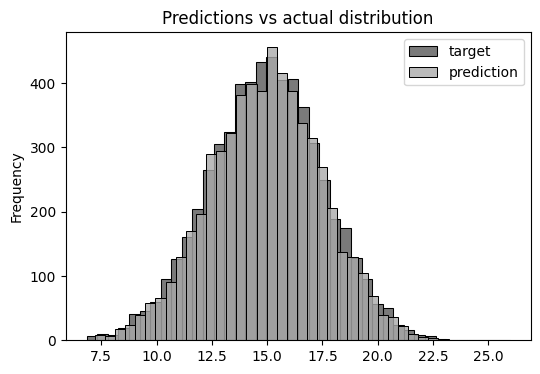

RMSR val  0.5173782638857467


In [61]:
X_train_zero = cars_train_zero.values
w_0, w = train_linear_regression(X_train_zero, y_train)

y_pred = w_0 + X_train_zero.dot(w)
print("RMSR train ", rmse(y_train, y_pred))
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('')
plt.title('Predictions vs actual distribution')

plt.show()

X_val_zero = cars_val_zero.values
y_pred = w_0 + X_val_zero.dot(w)
print("RMSR val ",rmse(y_val, y_pred))


RMSR train  0.4624412137959964


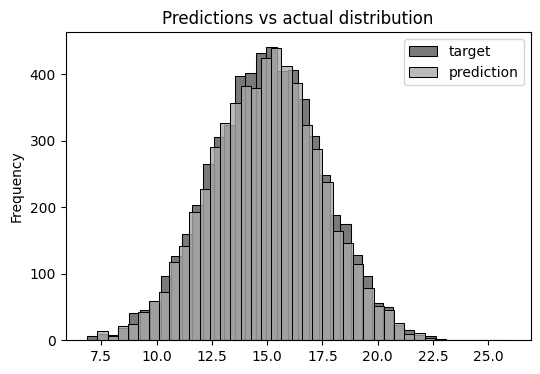

RMSR val  0.4636236995038883


In [59]:
X_train_mean = cars_train_mean.values
w_0, w = train_linear_regression(X_train_mean, y_train)

y_pred = w_0 + X_train_mean.dot(w)

print("RMSR train ", rmse(y_train, y_pred))
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('')
plt.title('Predictions vs actual distribution')

plt.show()


X_val_mean = cars_val_mean.values
y_pred = w_0 + X_val_mean.dot(w)
print("RMSR val ",rmse(y_val, y_pred))

In [60]:
y_val

array([15.36634109, 14.60118181, 12.24703219, ..., 13.61312692,
       13.73334321, 15.81604972], shape=(1940,))

# Regularization

In [45]:

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]


In [64]:
X_train = cars_train_zero.values
X_val_zero = cars_val_zero.values

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val_zero.dot(w)
    
    print("Regularizer: " , r, "RMSE: ", rmse(y_val,y_pred))

Regularizer:  0 RMSE:  0.5173782638857467
Regularizer:  0.01 RMSE:  0.5171115525767522
Regularizer:  0.1 RMSE:  0.5187525130701821
Regularizer:  1 RMSE:  0.5222348802092772
Regularizer:  5 RMSE:  0.5228916092823478
Regularizer:  10 RMSE:  0.5229812979636581
Regularizer:  100 RMSE:  0.5230636233819926


array([ 0.00015161,  0.00354204, -0.00500736,  0.01465133])

# Try different seeds

In [68]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [70]:
def train_model_seed(s):

    np.random.seed(s)
    n = len(cars_ds)

    n_val = int(0.2*n)
    n_test = int(0.2*n)
    n_train = n - (n_val + n_test)
    
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_shuffled = cars_ds.iloc[idx]
    df_shuffled['horsepower'] = df_shuffled['horsepower'].fillna(0)
    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test = df_shuffled.iloc[n_train+n_val:]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    
    # y_train = np.log1p
    del df_train['fuel_efficiency_mpg']
    del df_val["fuel_efficiency_mpg"]
    del df_test["fuel_efficiency_mpg"]

    
    X_train = df_train.values
    w_0, w = train_linear_regression(X_train, y_train)
    X_val = df_val.values
    y_pred = w_0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    print("RMSR ", score)
    return score

    

In [71]:
scores = []
for s in seeds:
    score = train_model_seed(s)
    scores.append(score)

RMSR  0.5206531296292951
RMSR  0.5213388912860217
RMSR  0.5228069974785726
RMSR  0.5159516741108942
RMSR  0.5109129460108117
RMSR  0.5283406460133415
RMSR  0.5313910658151165
RMSR  0.5090670387365963
RMSR  0.5147399129426932
RMSR  0.5131865908408015


In [76]:
np.std(scores)

np.float64(0.006989446425721602)

In [74]:
scores

[np.float64(0.5206531296292951),
 np.float64(0.5213388912860217),
 np.float64(0.5228069974785726),
 np.float64(0.5159516741108942),
 np.float64(0.5109129460108117),
 np.float64(0.5283406460133415),
 np.float64(0.5313910658151165),
 np.float64(0.5090670387365963),
 np.float64(0.5147399129426932),
 np.float64(0.5131865908408015)]

In [77]:
def train_model_seed_question6(s, r):

    np.random.seed(s)
    n = len(cars_ds)

    n_val = int(0.2*n)
    n_test = int(0.2*n)
    n_train = n - (n_val + n_test)
    
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_shuffled = cars_ds.iloc[idx]
    df_shuffled['horsepower'] = df_shuffled['horsepower'].fillna(0)
    # df_train = df_shuffled.iloc[:n_train].copy()
    # df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_train = df_shuffled.iloc[:n_train+n_val].copy()
    # df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test = df_shuffled.iloc[n_train+n_val:]

    y_train = df_train.fuel_efficiency_mpg.values
    # y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    
    # y_train = np.log1p
    del df_train['fuel_efficiency_mpg']
    # del df_val["fuel_efficiency_mpg"]
    del df_test["fuel_efficiency_mpg"]

    
    X_train = df_train.values
    w_0, w = train_linear_regression_reg(X_train, y_train, r)
    # X_val = df_val.values
    # y_pred = w_0 + X_val.dot(w)
    # score = rmse(y_val, y_pred)

    X_test = df_test.values
    y_pred = w_0 + X_test.dot(w)
    score = rmse(y_test, y_pred)
    print("RMSR ", score)
    return score


In [78]:
train_model_seed_question6(9,0.001)

RMSR  0.5156261299167999


np.float64(0.5156261299167999)